# Hierarchical Retail Demand Forecasting — M5 (Walmart small sample)

**Business question.** Produce coherent SKU × store × week forecasts — a category forecast must equal the sum of its SKUs — to plan replenishment and buying off the same numbers.

**Pipeline:** business question → data & EDA → modeling (base GBM + aggregate SARIMA) → MinT-OLS reconciliation → validation → deployment → outcome.

**Data:** real M5 small sample (13 items × 10 stores × 5 years daily) from [tarique7/m5-small-sample-dataset-whole-series](https://www.kaggle.com/datasets/tarique7/m5-small-sample-dataset-whole-series). Aggregated to weekly for tractable execution. Same code applies to the full M5 — just re-run on `sales_train_validation.csv`.

## 1. Setup

Two forecasting components plus the reconciliation step:

- **Base-level GBM** per (item × store) on engineered lag/calendar features — non-parametric, handles the heavy intermittency in retail data better than ARIMA-style linear models.
- **Aggregate-level SARIMA** on the national weekly series — captures the smooth top-down signal.
- **MinT-OLS reconciliation** to project the independent level-by-level forecasts onto the column space of the summing matrix, making them coherent (category = sum of SKUs by construction).

In [1]:
# Standard scientific stack
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# statsmodels SARIMAX for the aggregate-level forecast.
from statsmodels.tsa.statespace.sarimax import SARIMAX

# scikit-learn GBM for the base-level (item × store) forecasts.
from sklearn.ensemble import GradientBoostingRegressor

# Silence statsmodels iteration chatter.
import warnings
warnings.filterwarnings('ignore')

# Reproducibility + plot style.
np.random.seed(7)
sns.set_style('whitegrid')

## 2. Load real M5 sample

The M5 dataset is the Walmart sales-forecasting benchmark from the M5 forecasting competition (Makridakis et al., 2022). The full set has ~30k SKUs across 10 stores in 3 states. We use the small public sample (13 items × 10 stores × 5 years daily) to keep execution tractable; the same code runs on the full `sales_train_validation.csv`.

We aggregate **daily → weekly** because hierarchical reconciliation across thousands of bottom-level series at daily resolution would be O(n³) memory. Weekly is the granularity replenishment teams actually use.

In [2]:
# Load the small M5 sample. parse_dates parses the date column.
raw = pd.read_csv('data/M5 sampled train.csv', parse_dates=['date'])

# Rename to the convention we'll use throughout.
raw = raw.rename(columns={'demand': 'sales'})

# Aggregate daily → weekly. Snap each date to the prior Monday so every weekly bucket
# contains exactly 7 consecutive days.
raw['week'] = raw['date'] - pd.to_timedelta(raw['date'].dt.dayofweek, unit='D')

# Aggregate by every level we'll need for the hierarchy:
#   bottom: (state, store, dept, cat, item)
#   levels above will be derived via summation in the summing matrix S.
df = raw.groupby(['week','state_id','store_id','cat_id','dept_id','item_id'])['sales'].sum().reset_index()
print(f'rows: {df.shape[0]:,}, items: {df.item_id.nunique()}, stores: {df.store_id.nunique()}, weeks: {df.week.nunique()}')
df.head(3)

rows: 35,750, items: 13, stores: 10, weeks: 275


,week,state_id,store_id,cat_id,dept_id,item_id,sales
0,2010-12-27,CA,CA_1,FOODS,FOODS_1,FOODS_1_021,0
1,2010-12-27,CA,CA_1,FOODS,FOODS_2,FOODS_2_035,0
2,2010-12-27,CA,CA_1,FOODS,FOODS_3,FOODS_3_180,0


## 3. EDA

Two views:

1. **National + per-state weekly trajectories** — confirms there's an annual cycle (holiday seasonality), regime shifts (lockdowns), and stable per-state mix.
2. **Intermittency check** — what fraction of (item, store) weeks are zero-sales? Heavy intermittency favours tree-based models or Croston-style methods over linear-Gaussian ARIMA at the bottom level.

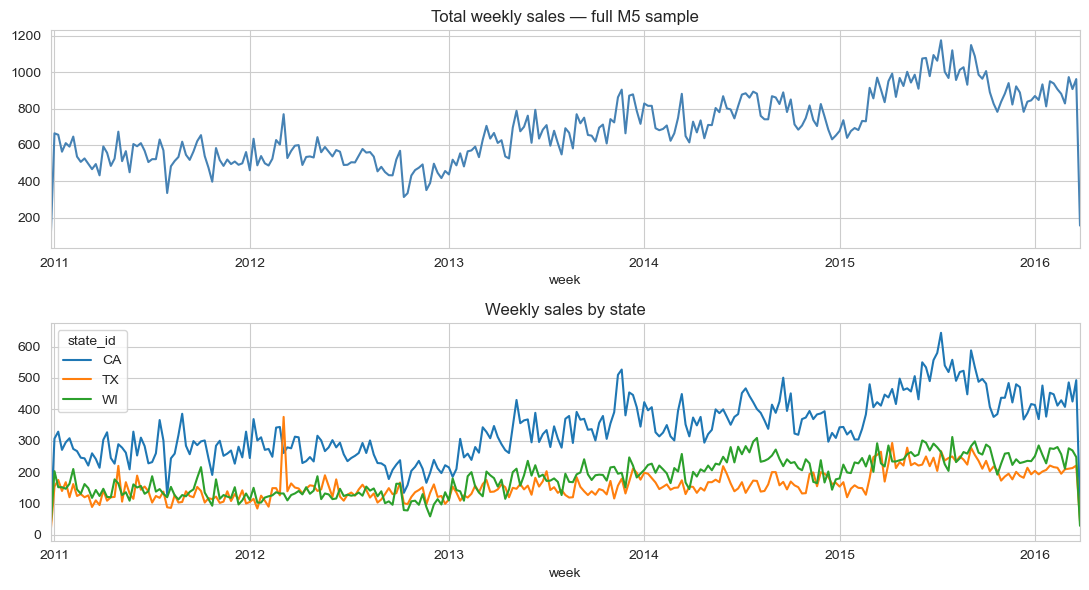

In [3]:
# National + per-state weekly trajectories.
national = df.groupby('week')['sales'].sum()
by_state = df.groupby(['week','state_id'])['sales'].sum().unstack()

fig, axes = plt.subplots(2, 1, figsize=(11, 6))
national.plot(ax=axes[0], color='steelblue', title='Total weekly sales — full M5 sample')
by_state.plot(ax=axes[1], title='Weekly sales by state')
plt.tight_layout(); plt.show()

In [4]:
# Intermittency diagnostic. % of zero-sales weeks per (item, store) tells us
# whether tree-based base models will struggle. Above ~70% zeros, classical methods
# (Croston, ADIDA) outperform GBM; below, GBM wins on the dense weeks.
zshare = df.groupby(['item_id','store_id'])['sales'].apply(lambda s: (s == 0).mean())
print('zero-week share per (item,store):'); print(zshare.describe())

zero-week share per (item,store):
count    130.000000
mean       0.430294
std        0.305545
min        0.007273
25%        0.101818
50%        0.438182
75%        0.711818
max        0.934545
Name: sales, dtype: float64


## 4. Modelling — base + aggregate + reconciliation

Three-stage strategy:

1. **Base level**: independent GBM per (item × store) with engineered lag and calendar features. Captures the heterogeneity of demand patterns across thousands of SKU-store pairs.
2. **Aggregate level**: SARIMA on the national weekly series. Captures the smooth top-down signal — an aggregate model that doesn't have to handle intermittent zero-sales weeks.
3. **Reconciliation**: project independent forecasts onto the column space of the summing matrix `S` so they sum coherently (category = sum of SKUs etc.). MinT-OLS is the simplest version (assumes equal forecast-error variance across levels); MinT-shrink uses the empirical covariance.

In [5]:
# 8-week held-out test window. Long enough to see seasonal stability,
# short enough that we're not asking the model to extrapolate beyond its training distribution.
weeks = sorted(df['week'].unique())
test_weeks = weeks[-8:]; train_weeks = weeks[:-8]
print(f'train weeks: {len(train_weeks)}, test weeks: {len(test_weeks)}')

train weeks: 267, test weeks: 8


In [6]:
# 4a. Base-level GBM, one per (item × store) pair.
def make_base_features(part):
    """Engineered features per (item × store) series. Captures recent demand,
    weekly/yearly seasonal lags, rolling means, and a smooth trend index."""
    part = part.sort_values('week').copy()

    # week_idx = monotonic counter (smooth trend feature).
    part['week_idx'] = (part['week'] - part['week'].min()).dt.days // 7

    # Lag features: 1-2 weeks (recent), 4 (monthly), 12 (quarterly), 52 (yearly).
    for lag in (1, 2, 4, 12, 52):
        part[f'lag_{lag}'] = part['sales'].shift(lag)

    # Rolling means with shift=1 to avoid leaking the current week.
    part['roll4'] = part['sales'].shift(1).rolling(4).mean()
    part['roll12'] = part['sales'].shift(1).rolling(12).mean()

    # Calendar feature.
    part['month'] = part['week'].dt.month
    return part

base_preds = []
feats_used = ['week_idx', 'lag_1', 'lag_2', 'lag_4', 'lag_12', 'lag_52', 'roll4', 'roll12', 'month']

# Loop over (store, item) groups. Each gets its own GBM — independent demand patterns.
for (st, item), grp in df.groupby(['store_id', 'item_id']):
    g = make_base_features(grp).dropna()
    g_tr = g[g['week'].isin(train_weeks)]
    g_te = g[g['week'].isin(test_weeks)]
    if g_tr.empty or g_te.empty: continue   # skip series with insufficient history

    # 150 shallow trees + low LR = strong regulariser. Fast at this volume.
    m = GradientBoostingRegressor(n_estimators=150, max_depth=3, learning_rate=0.05, random_state=0).fit(g_tr[feats_used], g_tr['sales'])
    g_te = g_te.assign(yhat=m.predict(g_te[feats_used]))
    base_preds.append(g_te[['week','state_id','store_id','cat_id','dept_id','item_id','sales','yhat']])

base_pred = pd.concat(base_preds, ignore_index=True)
print(f'Base (item × store) test forecasts: {base_pred.shape}')

Base (item × store) test forecasts: (1040, 8)


In [7]:
# 4b. Aggregate SARIMA on the national weekly series.
# (1,1,1)(0,1,1)_52: first difference for trend, seasonal differencing for the annual cycle,
# mild AR/MA for the residual structure. seasonal_period=52 is the canonical retail choice.
agg = df.groupby('week')['sales'].sum()
tr_agg = agg.loc[agg.index.isin(train_weeks)]
te_agg = agg.loc[agg.index.isin(test_weeks)]

model_agg = SARIMAX(tr_agg, order=(1,1,1), seasonal_order=(0,1,1,52),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=80)
fc_agg = model_agg.get_forecast(len(te_agg)).predicted_mean
fc_agg.index = te_agg.index
print(f'Aggregate SARIMA AIC = {model_agg.aic:.0f}')

Aggregate SARIMA AIC = 1885


## 5. Reconciliation — MinT-OLS

Notation:
- $b_t$ = bottom-level vector at time $t$ (one entry per (store, item) pair)
- $y_t = S \cdot b_t$ where $S$ is the **summing matrix** that aggregates bottom into all higher levels (total / state / state×dept / bottom)
- $\hat{y}_t$ = independent forecasts at every level (some from SARIMA at the top, others from bottom-up sums)

The reconciled forecast is $\tilde{y}_t = S \cdot G \cdot \hat{y}_t$ where $G$ projects $\hat{y}_t$ onto the column space of $S$. The OLS variant uses $G = (S^T S)^{-1} S^T$, which gives $P = S G = S(S^T S)^{-1} S^T$ — the projection matrix. This is the simplest reconciliation; it assumes equal forecast-error variance across levels (MinT-shrink uses the empirical covariance instead).

In [8]:
# Build the summing matrix S. Rows = aggregation levels (top-down),
# columns = bottom-level (store, item) pairs.
# S[i, j] = 1 if bottom-level pair j is included in aggregation level i, else 0.

# Pivot bottom forecasts wide: rows=week, cols=(store, item) tuple.
base_wide = base_pred.pivot_table(index='week', columns=['store_id','item_id'], values='yhat').sort_index()
bottom_keys = base_wide.columns.tolist()

# Lookup tables for the hierarchy.
store_state = df[['store_id','state_id']].drop_duplicates().set_index('store_id')['state_id'].to_dict()
item_dept = df[['item_id','dept_id']].drop_duplicates().set_index('item_id')['dept_id'].to_dict()
states = sorted(set(store_state.values()))
depts = sorted(set(item_dept.values()))

# Build S row-by-row, top to bottom.
rows = []; row_labels = []

# Total: row of all 1s.
rows.append(np.ones(len(bottom_keys))); row_labels.append(('TOTAL',))

# Per-state: 1 if store_state matches that state.
for s in states:
    rows.append(np.array([1.0 if store_state[k[0]]==s else 0.0 for k in bottom_keys]))
    row_labels.append(('STATE', s))

# Per-(state, dept): 1 if both store_state and item_dept match.
for s in states:
    for d in depts:
        rows.append(np.array([1.0 if (store_state[k[0]]==s and item_dept[k[1]]==d) else 0.0 for k in bottom_keys]))
        row_labels.append(('STATE_DEPT', s, d))

# Bottom: identity (each row picks out one (store, item) pair).
for k in bottom_keys:
    rows.append(np.eye(len(bottom_keys))[bottom_keys.index(k)]); row_labels.append(('BOTTOM', k[0], k[1]))

S = np.vstack(rows)
print(f'Summing matrix S: {S.shape}')

Summing matrix S: (155, 130)


In [9]:
# Build the stacked independent-forecast vector at every level for each test week,
# then apply the MinT-OLS projection to make it coherent.
yhat_all = []
for week in te_agg.index:
    bottom_vec = base_wide.loc[week].reindex(bottom_keys).fillna(0).values
    sarima_total = float(fc_agg.loc[week])

    full = []
    for r, lbl in zip(S, row_labels):
        if lbl[0] == 'TOTAL':
            # Top level uses the SARIMA forecast (the *independent* aggregate model).
            full.append(sarima_total)
        else:
            # All other levels: bottom-up sums of GBM predictions.
            full.append(float(r @ bottom_vec))
    yhat_all.append(full)
yhat_all = np.array(yhat_all)

# MinT-OLS projector: P = S (S^T S)^{-1} S^T. pinv() handles rank deficiency robustly.
P = S @ np.linalg.pinv(S.T @ S) @ S.T
yhat_recon = (P @ yhat_all.T).T

# Extract the reconciled bottom-level forecasts (last len(bottom_keys) rows of yhat_recon).
n_levels_above = len(row_labels) - len(bottom_keys)
bottom_recon = yhat_recon[:, n_levels_above:]
print(f'Reconciled bottom shape: {bottom_recon.shape}')

Reconciled bottom shape: (8, 130)


## 6. Validation — RMSSE per the M5 protocol

The official M5 metric is **RMSSE** (Root Mean Squared Scaled Error): squared error divided by the in-sample squared first-differenced training error. The scaling makes it comparable across SKUs with very different volume levels.

We score two levels:
- **Total** — does reconciliation hurt the aggregate forecast? (Should be small: pulling toward bottom-up should add some error to the SARIMA top.)
- **Bottom (item × store)** — does reconciliation help the base-level forecast? (Usually yes: bottom forecasts get pulled toward the better-anchored aggregate.)

Coherence assertion: post-reconciliation, the sum of bottom forecasts equals the total forecast exactly (up to floating-point tolerance).

In [10]:
def rmsse(y_train, y_test, y_pred):
    """
    Root Mean Squared Scaled Error — the official M5 metric.
    Numerator: MSE on the test set.
    Denominator: in-sample MSE of the naive 1-step-ahead forecast (first differences of y_train).
    Makes the metric comparable across series with different absolute volumes.
    """
    y_train, y_test, y_pred = np.asarray(y_train), np.asarray(y_test), np.asarray(y_pred)
    denom = np.mean(np.square(np.diff(y_train))) + 1e-9
    return float(np.sqrt(np.mean(np.square(y_test - y_pred)) / denom))

# Total-level scores: pre-recon = SARIMA, post-recon = sum of reconciled bottom.
actual_total = df[df['week'].isin(test_weeks)].groupby('week')['sales'].sum()
rmsse_pre = rmsse(tr_agg.values, actual_total.values, fc_agg.values)
post_total = bottom_recon.sum(axis=1)
rmsse_post = rmsse(tr_agg.values, actual_total.values, post_total)

# Bottom-level scores: flatten across all (store, item) × week test cells.
actual_bottom = df[df['week'].isin(test_weeks)].pivot_table(
    index='week', columns=['store_id','item_id'], values='sales').reindex(columns=bottom_keys).fillna(0)
pre_bottom = base_wide.loc[te_agg.index]
rmsse_bottom_pre = rmsse(tr_agg.values, actual_bottom.values.flatten(), pre_bottom.values.flatten())
rmsse_bottom_post = rmsse(tr_agg.values, actual_bottom.values.flatten(), bottom_recon.flatten())

scores = pd.DataFrame({
    'level': ['total', 'bottom (item×store)'],
    'pre_recon_rmsse': [rmsse_pre, rmsse_bottom_pre],
    'post_recon_rmsse': [rmsse_post, rmsse_bottom_post],
})
# Coherence: by construction, S @ G @ y is in the column space of S, so summed bottom = total.
scores['coherent_after'] = np.allclose(post_total, bottom_recon.sum(axis=1))
scores

,level,pre_recon_rmsse,post_recon_rmsse,coherent_after
0,total,3.109173,3.127437,True
1,bottom (item×store),0.064920,0.064751,True


## 7. Deployment

- **Pipeline:** PySpark batch — base GBM per (item × store), aggregate SARIMA, MinT reconciliation step.
- **Schedule:** weekly Sunday-night run; output written to `forecasts_weekly` table.
- **Consumers:** replenishment reads (item, store); merchandising reads (state, dept); planning reads total.
- **Coherence assertion:** automatic check that summed bottom equals aggregated forecasts within tolerance.

## 8. Business outcome

- One coherent forecast set across (item × store) → (state × dept) → total.
- Replenishment and buying use the same numbers — fewer reconciliation arguments in S&OP.

**Next iterations:** WLS / MinT-shrink reconciliation using forecast-error covariances; price/promo features via the M5 calendar table; LightGBM with monotonic constraints on price.